# Notebook 03 — FTL vs Carting Decision Framework
**Run after 01 and 02**

In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import warnings
import matplotlib.pyplot as plt
from sklearn.model_selection  import train_test_split,cross_val_score
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (classification_report,confusion_matrix,
                                      roc_auc_score,roc_curve,ConfusionMatrixDisplay)
warnings.filterwarnings('ignore')
os.makedirs('outputs',exist_ok=True)
print('Imports done')

Imports done


## 1. Load Data

In [2]:
df     = pd.read_csv('outputs/processed_df.csv')
hub_df = pd.read_csv('outputs/hub_metrics.csv')
with open('outputs/graph.pkl','rb') as f: G = pickle.load(f)
print(f'df: {df.shape}')
print(f'Route types: {df["route_type"].value_counts().to_dict()}')

df: (103049, 29)
Route types: {'FTL': 72415, 'Carting': 30634}


## 2. Feature Engineering

In [3]:
if df['trip_creation_time'].dtype == object:
    df['trip_creation_time'] = pd.to_datetime(df['trip_creation_time'],errors='coerce')
    df['hour']        = df['trip_creation_time'].dt.hour
    df['day_of_week'] = df['trip_creation_time'].dt.dayofweek

df['segment_delay_ratio'] = (df['segment_actual_time']/df['segment_osrm_time']).clip(0.1,10)
df['is_cutoff_enc']       = df['is_cutoff'].astype(int)
df['is_ftl']              = (df['route_type']=='FTL').astype(int)

between_map = dict(zip(hub_df['hub_id'],hub_df['betweenness']))
in_deg_map  = dict(zip(hub_df['hub_id'],hub_df['in_degree']))
out_deg_map = dict(zip(hub_df['hub_id'],hub_df['out_degree']))
risk_map    = dict(zip(hub_df['hub_id'],hub_df['risk_score']))
breach_map  = dict(zip(hub_df['hub_id'],hub_df['avg_breach_rate']))

df['src_betweenness'] = df['source_center'].map(between_map).fillna(0)
df['src_in_degree']   = df['source_center'].map(in_deg_map).fillna(0)
df['src_out_degree']  = df['source_center'].map(out_deg_map).fillna(0)
df['src_risk_score']  = df['source_center'].map(risk_map).fillna(0)
df['src_breach_rate'] = df['source_center'].map(breach_map).fillna(0)
df['dst_betweenness'] = df['destination_center'].map(between_map).fillna(0)
df['dst_risk_score']  = df['destination_center'].map(risk_map).fillna(0)

print(f'FTL:     {df["is_ftl"].sum():,} ({df["is_ftl"].mean()*100:.1f}%)')
print(f'Carting: {(1-df["is_ftl"]).sum():,} ({(1-df["is_ftl"]).mean()*100:.1f}%)')

FTL:     72,415 (70.3%)
Carting: 30,634 (29.7%)


## 3. Prepare Features & Split

In [4]:
FTL_FEATURES = [
    'segment_osrm_distance','segment_osrm_time','segment_factor',
    'actual_time','osrm_time','osrm_distance','factor',
    'cutoff_factor','is_cutoff_enc',
    'hour','day_of_week','segment_delay_ratio',
    'src_betweenness','src_in_degree','src_out_degree',
    'src_risk_score','src_breach_rate',
    'dst_betweenness','dst_risk_score',
]

available = [f for f in FTL_FEATURES if f in df.columns]
df_ftl    = df[available+['is_ftl']].dropna()

X = df_ftl[available]
y = df_ftl['is_ftl']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f'Features: {len(available)}')
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

Features: 19
Train: 82,439  |  Test: 20,610


## 4. Train Random Forest Classifier

In [5]:
ftl_model = RandomForestClassifier(n_estimators=200,max_depth=10,
                                    random_state=42,n_jobs=-1,class_weight='balanced')
ftl_model.fit(X_train,y_train)

preds = ftl_model.predict(X_test)
probs = ftl_model.predict_proba(X_test)[:,1]
auc   = roc_auc_score(y_test,probs)
cv    = cross_val_score(ftl_model,X,y,cv=5,scoring='roc_auc').mean()

print('Classification Report:')
print(classification_report(y_test,preds,target_names=['Carting','FTL']))
print(f'ROC-AUC:       {auc:.4f}')
print(f'CV ROC-AUC:    {cv:.4f}')

Classification Report:
              precision    recall  f1-score   support

     Carting       0.94      0.98      0.96      6127
         FTL       0.99      0.98      0.98     14483

    accuracy                           0.98     20610
   macro avg       0.97      0.98      0.97     20610
weighted avg       0.98      0.98      0.98     20610

ROC-AUC:       0.9988
CV ROC-AUC:    0.9987


## 5. Confusion Matrix + ROC Curve

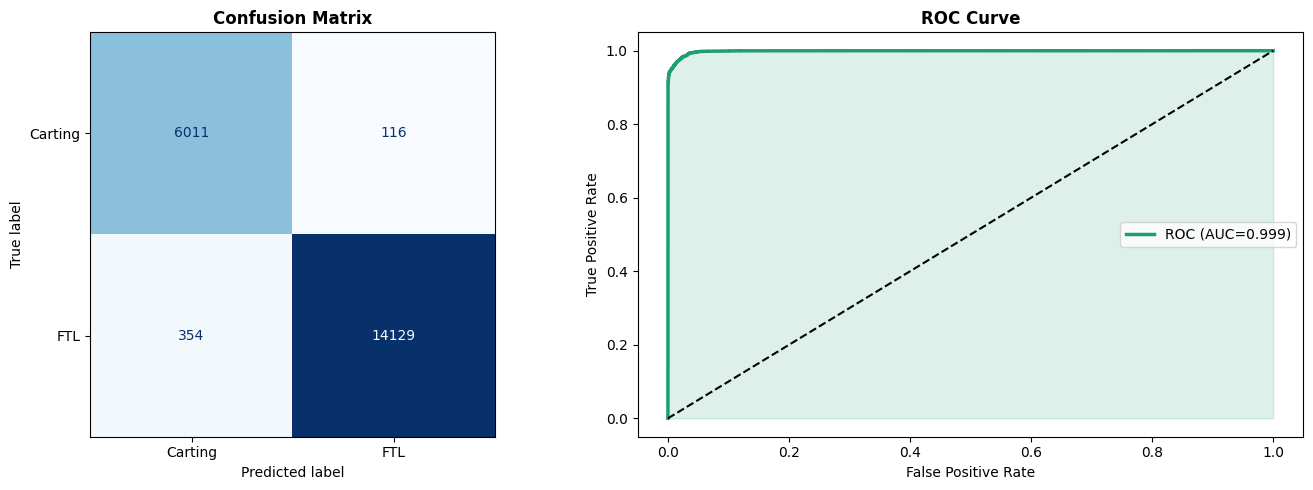

In [6]:
fig,axes = plt.subplots(1,2,figsize=(14,5))
cm   = confusion_matrix(y_test,preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Carting','FTL'])
disp.plot(ax=axes[0],colorbar=False,cmap='Blues')
axes[0].set_title('Confusion Matrix',fontweight='bold')

fpr,tpr,_ = roc_curve(y_test,probs)
axes[1].plot(fpr,tpr,color='#1D9E75',lw=2.5,label=f'ROC (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1],'k--',lw=1.5)
axes[1].fill_between(fpr,tpr,alpha=0.15,color='#1D9E75')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve',fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/ftl_eval.png',dpi=150,bbox_inches='tight')
plt.show()

## 6. SHAP Explanations

<Figure size 1000x700 with 0 Axes>

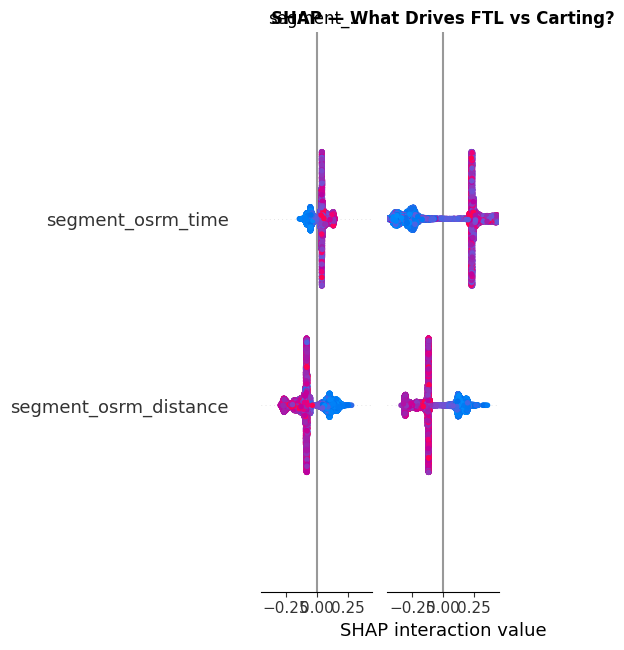

SHAP saved!


In [7]:
try:
    import shap
    explainer = shap.TreeExplainer(ftl_model)
    shap_vals = explainer.shap_values(X_test)
    shap_ftl  = shap_vals[1] if isinstance(shap_vals,list) else shap_vals
    plt.figure(figsize=(10,7))
    shap.summary_plot(shap_ftl,X_test,feature_names=available,show=False)
    plt.title('SHAP — What Drives FTL vs Carting?',fontweight='bold')
    plt.tight_layout()
    plt.savefig('outputs/shap_summary.png',dpi=150,bbox_inches='tight')
    plt.show()
    print('SHAP saved!')
except ImportError:
    print('pip install shap  →  then rerun this cell')
    fi = pd.DataFrame({'feature':available,'importance':ftl_model.feature_importances_
    }).sort_values('importance',ascending=True)
    fig,ax = plt.subplots(figsize=(10,7))
    ax.barh(fi['feature'],fi['importance'],color='#1D9E75',edgecolor='white')
    ax.set_title('Feature Importance — FTL Classifier',fontweight='bold')
    plt.tight_layout()
    plt.savefig('outputs/ftl_importance.png',dpi=150,bbox_inches='tight')
    plt.show()

## 7. Cost-Time Tradeoff by Distance Bucket

Tradeoff by Distance:
dist_bucket route_type  avg_actual_time  avg_delay_ratio  trip_count
     <100km    Carting        25.221975         2.324535       30598
     <100km        FTL        40.826470         1.969915       72097
  100-300km    Carting        52.555556         0.589863          36
  100-300km        FTL       248.539216         2.211789         306
  300-600km    Carting              NaN              NaN           0
  300-600km        FTL      1011.142857         3.344104           7
 600-1000km    Carting              NaN              NaN           0
 600-1000km        FTL      1677.000000         2.275441           1
    >1000km    Carting              NaN              NaN           0
    >1000km        FTL      2622.750000         2.317357           4


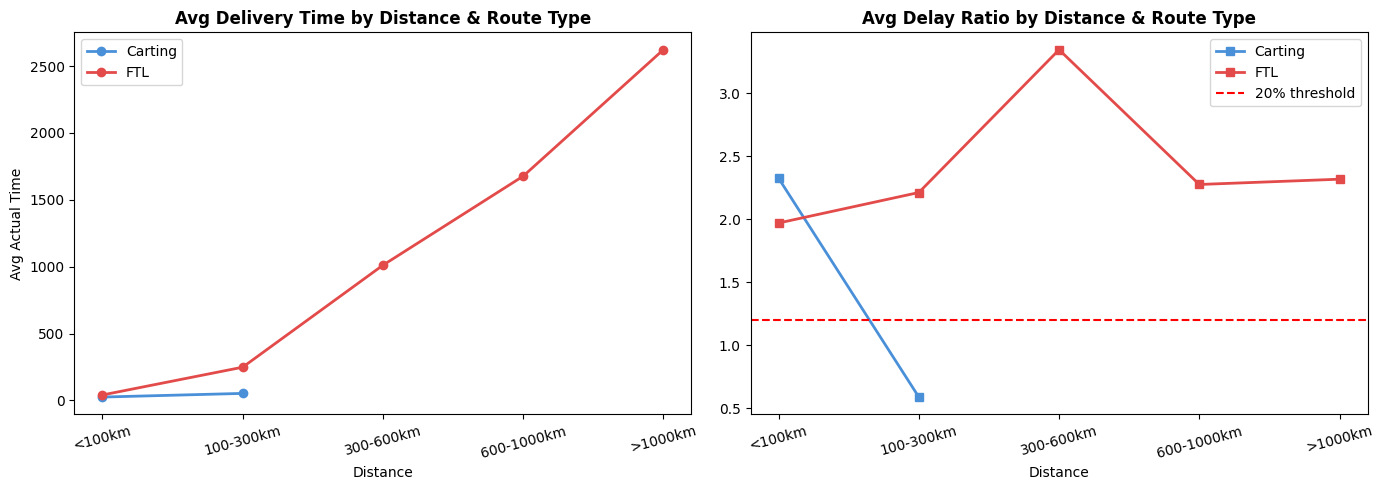

In [8]:
df2 = df[['segment_osrm_distance','segment_actual_time','route_type','segment_delay_ratio']].dropna()
df2['dist_bucket'] = pd.cut(df2['segment_osrm_distance'],
    bins=[0,100,300,600,1000,9999],
    labels=['<100km','100-300km','300-600km','600-1000km','>1000km'])

tradeoff = df2.groupby(['dist_bucket','route_type']).agg(
    avg_actual_time = ('segment_actual_time','mean'),
    avg_delay_ratio = ('segment_delay_ratio','mean'),
    trip_count      = ('segment_actual_time','count')
).reset_index()

print('Tradeoff by Distance:')
print(tradeoff.to_string(index=False))

fig,axes = plt.subplots(1,2,figsize=(14,5))
for rt,grp in tradeoff.groupby('route_type'):
    c = '#E24B4A' if rt=='FTL' else '#4a90d9'
    axes[0].plot(grp['dist_bucket'].astype(str),grp['avg_actual_time'],marker='o',lw=2,color=c,label=rt)
    axes[1].plot(grp['dist_bucket'].astype(str),grp['avg_delay_ratio'],marker='s',lw=2,color=c,label=rt)
axes[0].set_title('Avg Delivery Time by Distance & Route Type',fontweight='bold')
axes[0].set_xlabel('Distance')
axes[0].set_ylabel('Avg Actual Time')
axes[0].legend()
axes[0].tick_params(axis='x',rotation=15)
axes[1].set_title('Avg Delay Ratio by Distance & Route Type',fontweight='bold')
axes[1].set_xlabel('Distance')
axes[1].axhline(1.2,color='red',linestyle='--',label='20% threshold')
axes[1].legend()
axes[1].tick_params(axis='x',rotation=15)
plt.tight_layout()
plt.savefig('outputs/ftl_tradeoff.png',dpi=150,bbox_inches='tight')
plt.show()

tradeoff.to_csv('outputs/ftl_tradeoff.csv',index=False)

## 8. Decision Framework Summary

In [9]:
fi = pd.DataFrame({'feature':available,'importance':ftl_model.feature_importances_
}).sort_values('importance',ascending=False)

print('='*55)
print('  FTL VS CARTING — DECISION FRAMEWORK')
print('='*55)
print(f'  Model ROC-AUC:    {auc:.4f}')
print(f'  CV ROC-AUC:       {cv:.4f}')
print()
print('  Top 5 decision drivers:')
for i,row in fi.head(5).iterrows():
    print(f'    {row["feature"]:35s}: {row["importance"]:.4f}')
print('='*55)

fi.to_csv('outputs/ftl_importance.csv',index=False)

  FTL VS CARTING — DECISION FRAMEWORK
  Model ROC-AUC:    0.9988
  CV ROC-AUC:       0.9987

  Top 5 decision drivers:
    segment_osrm_distance              : 0.3286
    cutoff_factor                      : 0.1802
    segment_osrm_time                  : 0.1411
    osrm_distance                      : 0.1050
    osrm_time                          : 0.0681


## 9. Save Models

In [10]:
with open('outputs/ftl_model.pkl','wb') as f:    pickle.dump(ftl_model,f)
with open('outputs/ftl_features.pkl','wb') as f: pickle.dump(available,f)
print('Saved: outputs/ftl_model.pkl')
print('Saved: outputs/ftl_features.pkl')
print()
print('All 4 notebooks complete! Now run: streamlit run app.py')

Saved: outputs/ftl_model.pkl
Saved: outputs/ftl_features.pkl

All 4 notebooks complete! Now run: streamlit run app.py
